In [ ]:
# 1. Cài đặt các thư viện cần thiết (Colab thiếu vnstock, pandas_ta)
!pip install vnstock pandas_ta

In [ ]:
# 2. Kết nối với Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

# === CẤU HÌNH ĐƯỜNG DẪN QUAN TRỌNG ===
# Đây là nơi bạn lưu data trên Drive. Nếu bạn đặt tên folder khác, hãy sửa dòng này.
PROJECT_PATH = '/content/drive/MyDrive/ai_stock'

# Kiểm tra xem đường dẫn có đúng không
if os.path.exists(PROJECT_PATH):
    print(f"✅ Đã kết nối thành công tới folder: {PROJECT_PATH}")
    os.chdir(PROJECT_PATH) # Chuyển hướng làm việc vào folder này
    print(f"📂 Thư mục hiện tại: {os.getcwd()}")
else:
    print("❌ Lỗi: Không tìm thấy folder. Hãy kiểm tra lại tên folder trên Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã kết nối thành công tới folder: /content/drive/MyDrive/ai_stock
📂 Thư mục hiện tại: /content/drive/MyDrive/ai_stock


📂 Đang load dữ liệu từ: /content/drive/MyDrive/ai_stock/model_data...
   Train shape: X=(269274, 30, 17), y=(269274, 1)
   Test shape:  X=(36663, 30, 17),  y=(36663, 1)

🏗️ Đang xây dựng kiến trúc LSTM với Input: (30, 17)...

🚀 Bắt đầu Training trên Colab...
Epoch 1/100
4208/4208 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.7341e-04
Epoch 1: val_loss improved from inf to 0.00204, saving model to /content/drive/MyDrive/ai_stock/models/best_lstm_model.keras
4208/4208 ━━━━━━━━━━━━━━━━━━━━ 38s 9ms/step - loss: 5.7332e-04 - val_loss: 0.0020
Epoch 2/100
4206/4208 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.4983e-05
Epoch 2: val_loss did not improve from 0.00204
4208/4208 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - loss: 7.4977e-05 - val_loss: 0.0028
Epoch 3/100
4206/4208 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.1810e-05
Epoch 3: val_loss did not improve from 0.00204
4208/4208 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - loss: 5.1808e-05 - val_loss: 0.0027
Epoch 4/100
4207/4208 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

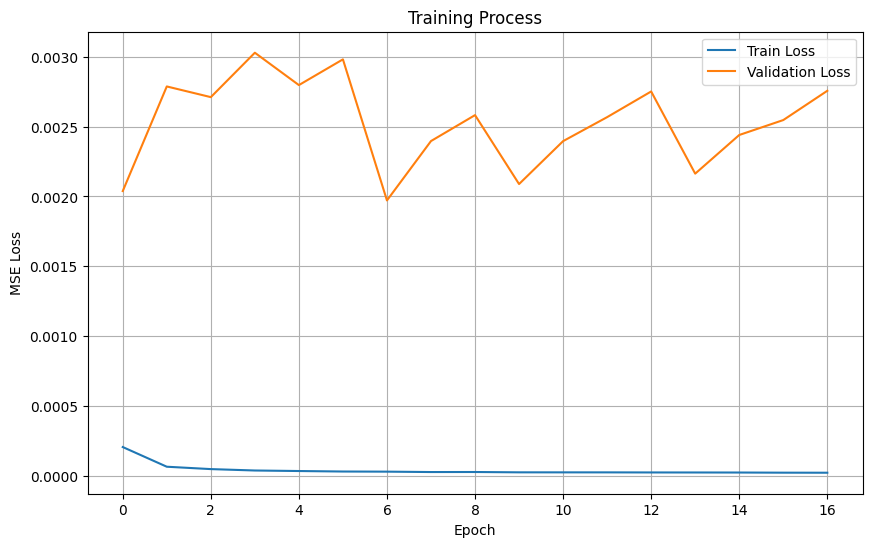

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Tắt warning
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Đường dẫn folder (Lấy từ Cell 1)
BASE_DIR = os.getcwd()

def load_data():
    print(f"📂 Đang load dữ liệu từ: {os.path.join(BASE_DIR, 'model_data')}...")
    try:
        # Load dữ liệu từ đường dẫn tuyệt đối
        X_train = np.load(os.path.join(BASE_DIR, 'model_data/X_train.npy'))
        y_train = np.load(os.path.join(BASE_DIR, 'model_data/y_train.npy'))
        X_test = np.load(os.path.join(BASE_DIR, 'model_data/X_test.npy'))
        y_test = np.load(os.path.join(BASE_DIR, 'model_data/y_test.npy'))

        print(f"   Train shape: X={X_train.shape}, y={y_train.shape}")
        print(f"   Test shape:  X={X_test.shape},  y={y_test.shape}")
        return X_train, y_train, X_test, y_test
    except FileNotFoundError:
        print("❌ Lỗi: Không tìm thấy file trong folder 'model_data' trên Drive.")
        return None, None, None, None

def build_model(input_shape):
    print(f"\n🏗️ Đang xây dựng kiến trúc LSTM với Input: {input_shape}...")
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=25, activation='relu'))
    model.add(Dense(units=1))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    return model

# --- MAIN PROCESS ---
X_train, y_train, X_test, y_test = load_data()

if X_train is not None:
    # Build Model
    model = build_model((X_train.shape[1], X_train.shape[2]))

    # Tạo folder models trên Drive nếu chưa có
    models_dir = os.path.join(BASE_DIR, 'models')
    os.makedirs(models_dir, exist_ok=True)

    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Lưu model trực tiếp vào Drive
    checkpoint_path = os.path.join(models_dir, 'best_lstm_model.keras')
    checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)

    print("\n🚀 Bắt đầu Training trên Colab...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=64,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    # Vẽ và lưu biểu đồ
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training Process')
    plt.ylabel('MSE Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)

    chart_path = os.path.join(models_dir, 'training_loss.png')
    plt.savefig(chart_path)
    print(f"✅ Đã lưu biểu đồ loss tại: {chart_path}")
    print(f"✅ Model đã lưu tại: {checkpoint_path}")

In [ ]:
# ==========================================
# 1. CÀI ĐẶT MÔI TRƯỜNG (CHẠY 1 LẦN)
# ==========================================
!pip install scikit-learn==1.5.2 pandas_ta vnstock

In [ ]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
from datetime import datetime
import os

# --- CẤU HÌNH ---
TICKER = 'HPG'       # Mã muốn dự báo
LOOKBACK = 30
BASE_DIR = os.getcwd()

print(f"🔄 Đang khởi tạo dự báo cho mã {TICKER} từ Drive...")

try:
    # 2. Load Resources
    model_path = os.path.join(BASE_DIR, 'models/best_lstm_model.keras')
    data_path = os.path.join(BASE_DIR, 'data/vn100_with_vietnam_macro.csv')
    feat_scaler_path = os.path.join(BASE_DIR, 'model_data/feature_scaler.pkl')
    targ_scaler_path = os.path.join(BASE_DIR, 'model_data/target_scaler.pkl')

    # Load file
    model = load_model(model_path)
    feature_scaler = joblib.load(feat_scaler_path)
    target_scaler = joblib.load(targ_scaler_path)
    df = pd.read_csv(data_path)
    df['time'] = pd.to_datetime(df['time'])

    print(f"✅ Đã load file data.")

except Exception as e:
    print(f"❌ Lỗi load file: {e}")
    print("👉 Hãy kiểm tra folder 'models', 'data', 'model_data' trên Drive.")
    raise e

# 3. Lấy dữ liệu 30 ngày cuối
df_ticker = df[df['ticker'] == TICKER].sort_values('time')
last_30_days = df_ticker.tail(LOOKBACK).copy()

if len(last_30_days) < LOOKBACK:
    print(f"❌ Không đủ dữ liệu (Cần {LOOKBACK}, có {len(last_30_days)})")
else:
    last_date = last_30_days.iloc[-1]['time']
    print(f"📅 Dữ liệu input đến ngày: {last_date.strftime('%Y-%m-%d')}")

    # --- DANH SÁCH FEATURE CHUẨN CỦA MODEL ---
    REQUIRED_FEATURES = [
        'open', 'high', 'low', 'close', 'volume',
        'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9',
        'BBU_20_2.0', 'BBL_20_2.0', 'ATR_14',
        'vnindex_return', 'banking_return', 'realestate_return',
        'retail_return', 'steel_return', 'securities_return'
    ]

    # --- LOGIC MAP TÊN CỘT (PHẦN ĐÃ SỬA) ---
    actual_cols = last_30_days.columns.tolist()
    final_features = []

    print("\n🔍 Kiểm tra và Map tên cột:")
    for col in REQUIRED_FEATURES:
        if col in actual_cols:
            final_features.append(col)
        else:
            # === ĐÂY LÀ PHẦN SỬA ĐỔI ===
            alt_col = None

            # 1. Check lỗi tên BB bị lặp (Lỗi bạn đang gặp)
            if col == 'BBU_20_2.0' and 'BBU_20_2.0_2.0' in actual_cols:
                alt_col = 'BBU_20_2.0_2.0'
            elif col == 'BBL_20_2.0' and 'BBL_20_2.0_2.0' in actual_cols:
                alt_col = 'BBL_20_2.0_2.0'

            # 2. Check lỗi ATR có chữ r
            elif col == 'ATR_14' and 'ATRr_14' in actual_cols:
                alt_col = 'ATRr_14'

            # 3. Check lỗi thiếu đuôi .0 (Dự phòng)
            elif col == 'BBU_20_2.0' and 'BBU_20_2' in actual_cols:
                alt_col = 'BBU_20_2'
            elif col == 'BBL_20_2.0' and 'BBL_20_2' in actual_cols:
                alt_col = 'BBL_20_2'

            # Xử lý đổi tên
            if alt_col:
                print(f"   ⚠️ Đổi tên cột '{alt_col}' -> '{col}'")
                last_30_days.rename(columns={alt_col: col}, inplace=True)
                final_features.append(col)
            else:
                print(f"   ❌ LỖI: Không tìm thấy cột '{col}'")

    # Nếu thiếu cột thì dừng lại
    if len(final_features) != len(REQUIRED_FEATURES):
        print("❌ Dữ liệu thiếu cột quan trọng. Không thể dự báo.")
    else:
        # 4. Scale & Reshape
        try:
            input_scaled = feature_scaler.transform(last_30_days[REQUIRED_FEATURES])
            input_sequence = np.array([input_scaled]) # (1, 30, 17)

            # 5. Predict
            pred_scaled = model.predict(input_sequence, verbose=0)
            pred_price = target_scaler.inverse_transform(pred_scaled)[0][0]

            # 6. Kết quả
            curr_price = last_30_days.iloc[-1]['close']
            pct_change = ((pred_price - curr_price) / curr_price) * 100

            print("\n" + "="*40)
            print(f"📢 KẾT QUẢ DỰ BÁO TRÊN COLAB ({TICKER})")
            print(f"   Giá hiện tại: {curr_price:,.0f} VND")
            print(f"   Giá dự báo:   {pred_price:,.0f} VND")
            print(f"   Biến động:    {pct_change:+.2f}%")
            print("="*40)

        except Exception as e:
            print(f"❌ Lỗi khi chạy model: {e}")

🔄 Đang khởi tạo dự báo cho mã HPG từ Drive...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ Đã load file data.
📅 Dữ liệu input đến ngày: 2025-12-31

🔍 Kiểm tra và Map tên cột:
   ⚠️ Đổi tên cột 'BBU_20_2.0_2.0' -> 'BBU_20_2.0'
   ⚠️ Đổi tên cột 'BBL_20_2.0_2.0' -> 'BBL_20_2.0'
   ⚠️ Đổi tên cột 'ATRr_14' -> 'ATR_14'

📢 KẾT QUẢ DỰ BÁO TRÊN COLAB (HPG)
   Giá hiện tại: 26 VND
   Giá dự báo:   22 VND
   Biến động:    -15.67%
